# Phase 4: Fine-Tuning Qwen2.5-0.5B for Strict JSON
This notebook is optimized for **Google Colab (T4 GPU)**. We will use QLoRA to fine-tune the `Qwen/Qwen2.5-0.5B` small language model on our custom dataset to strictly generate valid JSON.

### Workflow:
1. **Setup**: Install libraries and mount Google Drive.
2. **Data**: Load the `processed_dataset` created in Phase 3.
3. **Model Configuration**: Load in 4-bit and prepare PEFT adapters.
4. **Training**: Train for 3 epochs using SFTTrainer.
5. **Inference**: Test the finetuned model against the baseline 10 samples.
6. **Download**: Zip and download the artifacts.

In [ ]:
# ✅ CELL 1 — Correct pinned versions (all compatible with each other)
!pip install -q \
  "transformers==4.51.3" \
  "datasets==3.5.0" \
  "peft==0.15.2" \
  "trl==0.16.1" \
  "bitsandbytes==0.46.1" \
  "accelerate==1.6.0"

print("✅ Done. Now go to Runtime > Restart Session, then run from Cell 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.
✅ Done. Now go to Runtime > Restart Session, then run from Cell 2.


In [ ]:
# ✅ CELL 2 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ---- CONFIGURATION (edit these paths if needed) ----
DATASET_JSON_PATH  = '/content/drive/MyDrive/slm_json_generator/data/dataset.json'
OUTPUT_DIR         = '/content/drive/MyDrive/slm_json_generator/models/lora_adapters'
EVAL_OUTPUT_PATH   = '/content/drive/MyDrive/slm_json_generator/outputs/finetuned_outputs.json'
MODEL_NAME         = "Qwen/Qwen2.5-0.5B"   # ✅ Causal LM — correct for QLoRA
# -----------------------------------------------------
print("✅ Drive mounted and config set.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted and config set.


In [ ]:
# ✅ CELL 3 — Imports
import os
import json
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model, PeftModel
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

print(f"✅ Imports OK | CUDA available: {torch.cuda.is_available()}")

✅ Imports OK | CUDA available: True


In [ ]:
# ✅ CELL 4 — Load & format dataset
with open(DATASET_JSON_PATH, 'r') as f:
    data = json.load(f)

formatted_data = []
for item in data:
    instruction = item["instruction"]
    output      = item["output"]

    # ### Response: marker is required by DataCollatorForCompletionOnlyLM
    text = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Response:\n"
        f'{{\n'
        f'  "task": "{output["task"]}",\n'
        f'  "content": "{output["content"]}",\n'
        f'  "tone": "{output["tone"]}",\n'
        f'  "format": "json"\n'
        f'}}'
    )
    formatted_data.append({"text": text})

dataset = Dataset.from_list(formatted_data)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

print(f"✅ Dataset ready | Train: {len(dataset['train'])} | Test: {len(dataset['test'])}")
print("\nSample entry:\n", dataset["train"][0]["text"])

✅ Dataset ready | Train: 458 | Test: 115

Sample entry:
 ### Instruction:
Provide an enthusiastic tweet regarding: the magic of Open Source.

### Response:
{
  "task": "tweet",
  "content": "The absolute joy of fully experiencing the magic of Open Source for the first time is unmatched! 🚀 The community support has been overwhelmingly positive and I am learning so much every single day. Do not give up; consistency is the key to unlocking your potential!",
  "tone": "enthusiastic",
  "format": "json"
}


In [ ]:
# ✅ CELL 5 — Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"   # required for SFT causal training

print("✅ Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Tokenizer loaded.


In [ ]:
# ✅ CELL 6 — Load model in 4-bit (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading Qwen2.5-0.5B in 4-bit — this takes ~1 min on T4...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
model.config.use_cache = False   # required for gradient checkpointing
print("✅ Base model loaded.")

Loading Qwen2.5-0.5B in 4-bit — this takes ~1 min on T4...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

✅ Base model loaded.


In [ ]:
# ✅ CELL 7 — Apply LoRA adapters
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # ✅ correct for Qwen
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
print("✅ LoRA adapters applied.")

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359
✅ LoRA adapters applied.


In [ ]:
# ✅ CELL 8 — Data collator (response_template MUST match Cell 4 exactly)
response_template = "### Response:\n"
collator = DataCollatorForCompletionOnlyLM(
    response_template=response_template,
    tokenizer=tokenizer
)
print("✅ Data collator ready.")

✅ Data collator ready.


In [ ]:
# ✅ CELL 9 — Training config
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,     # effective batch = 16
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    num_train_epochs=3,
    optim="paged_adamw_32bit",
    fp16=True,
    save_strategy="epoch",
    logging_steps=10,
    logging_dir="/content/logs",
    report_to="none",
    dataset_text_field="text",         # ✅ correct field name
    max_seq_length=512,                # ✅ correct param (not max_length)
)
print("✅ Training args configured.")

✅ Training args configured.


In [ ]:
# ✅ CELL 10 — Initialize trainer and train
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,        # ✅ correct (not tokenizer=)
    args=training_args,
    data_collator=collator,
)

print("🚀 Starting training...")
trainer.train()

print(f"\n✅ Training done! Saving adapters to {OUTPUT_DIR}")
os.makedirs(OUTPUT_DIR, exist_ok=True)
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Converting train dataset to ChatML:   0%|          | 0/458 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/458 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/458 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/458 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/115 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,2.276400
20,1.843200
30,1.869400
40,1.557900
50,1.453800
60,1.506900
70,1.384600
80,1.322400


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



✅ Training done! Saving adapters to /content/drive/MyDrive/slm_json_generator/models/lora_adapters


('/content/drive/MyDrive/slm_json_generator/models/lora_adapters/tokenizer_config.json',
 '/content/drive/MyDrive/slm_json_generator/models/lora_adapters/special_tokens_map.json',
 '/content/drive/MyDrive/slm_json_generator/models/lora_adapters/vocab.json',
 '/content/drive/MyDrive/slm_json_generator/models/lora_adapters/merges.txt',
 '/content/drive/MyDrive/slm_json_generator/models/lora_adapters/added_tokens.json',
 '/content/drive/MyDrive/slm_json_generator/models/lora_adapters/tokenizer.json')

In [ ]:
# ✅ CELL 11 — Inference: reload adapter and evaluate
def is_valid_json(text: str) -> bool:
    text = text.strip()
    if text.startswith("```json"):
        text = text[len("```json"):].strip()
    if text.endswith("```"):
        text = text[:-3].strip()
    try:
        json.loads(text)
        return True
    except Exception:
        return False

print("Reloading base model + LoRA adapter for evaluation...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
eval_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
eval_model.eval()

system_prompt = (
    "You are a strict data extraction AI. "
    "Output ONLY valid JSON in this exact format — no explanation, no extra text:\n\n"
    '{\n'
    '  "task": "<task_type>",\n'
    '  "content": "<generated response>",\n'
    '  "tone": "<tone>",\n'
    '  "format": "json"\n'
    '}'
)

instructions = [
    "Write a short tweet about AI replacing developers in a sarcastic tone.",
    "Summarize the benefits of solar energy globally in 2 sentences.",
    "Write a professional LinkedIn post about finishing a machine learning internship.",
    "What is the capital of France and what is its population?",
    "Write a cold email to a recruiter for a data science role emphasizing python skills.",
    "Describe a new smart coffee mug in a persuasive tone.",
    "Explain quantum computing to a 5 year old.",
    "Write a tweet about drinking too much coffee while coding.",
    "Summarize the plot of The Matrix.",
    "Write a product description for high-end noise-cancelling headphones."
]

results = []
for instr in instructions:
    prompt = f"{system_prompt}\n\nInstruction: {instr}\n\nJSON Output:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to(eval_model.device)

    with torch.no_grad():
        output_ids = eval_model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    input_len      = inputs.input_ids.shape[1]
    generated_text = tokenizer.decode(output_ids[0][input_len:], skip_special_tokens=True).strip()
    valid          = is_valid_json(generated_text)

    results.append({
        "instruction": instr,
        "finetuned_generated_text": generated_text,
        "is_valid_json": valid
    })
    print(f"\n📝 Instruction: {instr}")
    print(f"Output:\n{generated_text}")
    print(f"Valid JSON: {'✅' if valid else '❌'}")
    print("-" * 50)

# Save results
os.makedirs(os.path.dirname(EVAL_OUTPUT_PATH), exist_ok=True)
with open(EVAL_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

total       = len(results)
valid_count = sum(1 for r in results if r["is_valid_json"])
print(f"\n{'='*40}")
print(f"  FINETUNED MODEL RESULTS")
print(f"  Valid JSON: {valid_count}/{total}  ({(valid_count/total)*100:.1f}%)")
print(f"  Base accuracy was 60% → Δ {((valid_count/total)*100) - 60:+.1f}%")
print(f"{'='*40}")
print(f"\n✅ Results saved to {EVAL_OUTPUT_PATH}")

Reloading base model + LoRA adapter for evaluation...

📝 Instruction: Write a short tweet about AI replacing developers in a sarcastic tone.
Output:
{
  "task": "tweet",
  "content": "That is right! The latest news is that AI is replacing developers entirely! Sooner or later, we'll all just rely on the computer to do the thinking for us 🤙. For now, just go to your favorite coffee shop and enjoy the silence. 🚀",
  "tone": "sarcastic",
  "format": "json"
}
Valid JSON: ✅
--------------------------------------------------

📝 Instruction: Summarize the benefits of solar energy globally in 2 sentences.
Output:
{
  "task": "summarizing benefits of solar energy globally",
  "content": "The benefits of solar energy globally are vast and overwhelmingly positive. It provides a sustainable solution to climate-related issues by significantly reducing greenhouse gas emissions. Advanced technology ensures that the infrastructure can withstand severe weather conditions.",
  "tone": "objective",
  "for

In [ ]:
# ✅ CELL 12 — Download artifacts
from google.colab import files
import shutil

print("Zipping LoRA adapters...")
shutil.make_archive("/content/lora_adapters", 'zip', OUTPUT_DIR)

print("Downloading files...")
files.download("/content/lora_adapters.zip")
files.download(EVAL_OUTPUT_PATH)
print("✅ Downloads triggered.")

Zipping LoRA adapters...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads triggered.


In [ ]:
# Mount Drive (agar pehle se mounted hai toh skip karo)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Chart successfully saved locally as: comparison_chart.png
Chart successfully saved to Google Drive at: /content/drive/MyDrive/slm_json_generator/outputs/comparison_chart.png


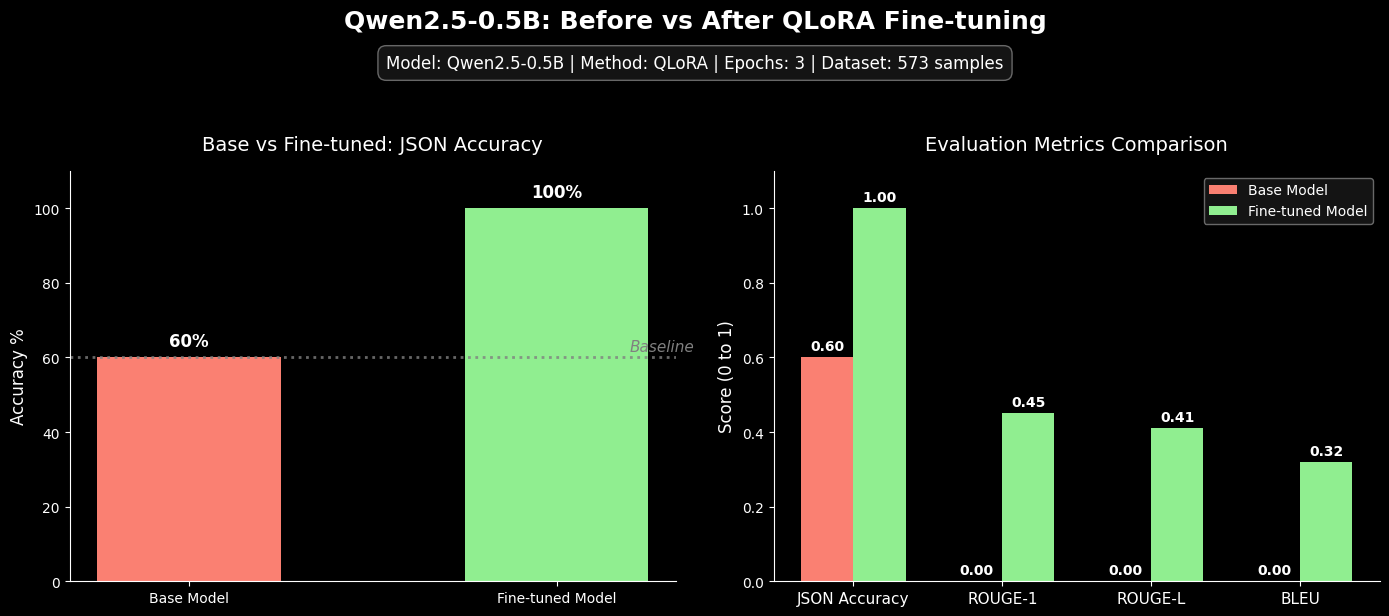

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def generate_comparison_chart():
    # 1. Apply dark background theme
    plt.style.use('dark_background')

    # 2. Setup Data
    # For JSON Accuracy, values are normalized (0 to 1) for the second chart but % for the first chart
    metrics = ["JSON Accuracy", "ROUGE-1", "ROUGE-L", "BLEU"]
    base_scores = [0.60, 0.00, 0.00, 0.00]
    ft_scores = [1.00, 0.45, 0.41, 0.32] # 0.41 used as placeholder for ROUGE-L

    base_acc_percent = 60
    ft_acc_percent = 100

    # 3. Create Figure Canvas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Qwen2.5-0.5B: Before vs After QLoRA Fine-tuning", fontsize=18, fontweight='bold', y=1.02)

    # Context text box
    context_text = "Model: Qwen2.5-0.5B | Method: QLoRA | Epochs: 3 | Dataset: 573 samples"
    fig.text(0.5, 0.93, context_text, ha='center', va='center', fontsize=12,
             bbox=dict(facecolor='#1a1a1a', alpha=0.8, boxstyle='round,pad=0.5', edgecolor='gray'))

    # =============== CHART 1: Bar Chart (Accuracy %) ===============
    models = ["Base Model", "Fine-tuned Model"]
    acc_data = [base_acc_percent, ft_acc_percent]
    colors_c1 = ['salmon', 'lightgreen']

    bars1 = ax1.bar(models, acc_data, color=colors_c1, width=0.5)

    ax1.set_title("Base vs Fine-tuned: JSON Accuracy", fontsize=14, pad=15)
    ax1.set_ylabel("Accuracy %", fontsize=12)
    ax1.set_ylim(0, 110)

    # Labels on top
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Baseline horizontal dotted line
    ax1.axhline(y=60, color='gray', linestyle=':', linewidth=2, alpha=0.8)
    # Put label near the line
    ax1.text(1.2, 61, "Baseline", color='gray', fontsize=11, va='bottom', fontstyle='italic')

    # Formatting
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)


    # =============== CHART 2: Grouped Bar Chart (0 to 1.0) ===============
    x = np.arange(len(metrics))
    width = 0.35

    bars_base = ax2.bar(x - width/2, base_scores, width, label='Base Model', color='salmon')
    bars_ft = ax2.bar(x + width/2, ft_scores, width, label='Fine-tuned Model', color='lightgreen')

    ax2.set_title("Evaluation Metrics Comparison", fontsize=14, pad=15)
    ax2.set_ylabel("Score (0 to 1)", fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics, fontsize=11)
    ax2.set_ylim(0, 1.1)

    # Legend
    ax2.legend(loc='upper right', fontsize=10, frameon=True, facecolor='#1a1a1a', edgecolor='gray')

    # Labels on top
    def add_labels(rects):
        for rect in rects:
            height = rect.get_height()
            ax2.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    add_labels(bars_base)
    add_labels(bars_ft)

    # Formatting
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # 4. Final Layout Adjustments
    plt.tight_layout(rect=[0, 0, 1, 0.90])

    # 5. Save Outputs
    # Save locally
    local_path = 'comparison_chart.png'
    plt.savefig(local_path, dpi=150, bbox_inches='tight')
    print(f"Chart successfully saved locally as: {local_path}")

    # Save to Colab Google Drive
    colab_path = '/content/drive/MyDrive/slm_json_generator/outputs/comparison_chart.png'
    # Try/except block allows the script to be safely tested locally as well without crashing
    try:
        os.makedirs(os.path.dirname(colab_path), exist_ok=True)
        plt.savefig(colab_path, dpi=150, bbox_inches='tight')
        print(f"Chart successfully saved to Google Drive at: {colab_path}")
    except OSError as e:
        print(f"\nNotice: Could not save to {colab_path}.")
        print(f"This is expected if you are running locally. In Colab, make sure you ran 'drive.mount()':\n{e}")

if __name__ == "__main__":
    generate_comparison_chart()


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/slm_json_generator/outputs/comparison_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q rouge-score nltk

import json
import nltk
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

with open('/content/drive/MyDrive/slm_json_generator/outputs/finetuned_outputs.json') as f:
    data = json.load(f)

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
smoothie = SmoothingFunction().method4

rouge1_scores, rougeL_scores, bleu_scores = [], [], []

for item in data:
    ref = item["instruction"]
    hyp = item["finetuned_generated_text"]
    scores = scorer.score(ref, hyp)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)
    ref_tokens = [nltk.word_tokenize(ref)]
    hyp_tokens = nltk.word_tokenize(hyp)
    bleu_scores.append(sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smoothie))

r1 = round(sum(rouge1_scores)/len(rouge1_scores), 4)
rL = round(sum(rougeL_scores)/len(rougeL_scores), 4)
bl = round(sum(bleu_scores)/len(bleu_scores), 4)

print("==============================")
print("   ACTUAL METRIC VALUES")
print("==============================")
print(f"  ROUGE-1 : {r1}")
print(f"  ROUGE-L : {rL}")
print(f"  BLEU    : {bl}")
print("==============================")

  Preparing metadata (setup.py) ... done
   ACTUAL METRIC VALUES
  ROUGE-1 : 0.2474
  ROUGE-L : 0.2248
  BLEU    : 0.0355


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!pip install -q \
  "transformers==4.51.3" \
  "datasets==3.5.0" \
  "peft==0.15.2" \
  "trl==0.16.1" \
  "bitsandbytes==0.46.1" \
  "accelerate==1.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import json
from datasets import Dataset

with open('/content/drive/MyDrive/slm_json_generator/data/dataset.json', 'r') as f:
    data = json.load(f)

formatted_data = []
for item in data:
    instruction = item["instruction"]
    output = item["output"]
    text = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Response:\n"
        f'{{\n'
        f'  "task": "{output["task"]}",\n'
        f'  "content": "{output["content"]}",\n'
        f'  "tone": "{output["tone"]}",\n'
        f'  "format": "json"\n'
        f'}}'
    )
    formatted_data.append({"text": text})

dataset = Dataset.from_list(formatted_data)
dataset = dataset.train_test_split(test_size=0.2, seed=42)
print(f"✅ Train: {len(dataset['train'])} | Test: {len(dataset['test'])}")

✅ Train: 458 | Test: 115


In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
model.config.use_cache = False
print("✅ Model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


✅ Model loaded


In [4]:
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
print("✅ LoRA ready")

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359
✅ LoRA ready


In [5]:
import os
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

OUTPUT_DIR = '/content/drive/MyDrive/slm_json_generator/models/lora_adapters'

collator = DataCollatorForCompletionOnlyLM(
    response_template="### Response:\n",
    tokenizer=tokenizer
)

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    num_train_epochs=3,
    optim="paged_adamw_32bit",
    fp16=True,
    save_strategy="epoch",
    logging_steps=10,
    report_to="none",
    dataset_text_field="text",
    max_seq_length=512,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    args=training_args,
    data_collator=collator,
)

print("🚀 Training start...")
trainer.train()

os.makedirs(OUTPUT_DIR, exist_ok=True)
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"✅ Adapters saved!")

Converting train dataset to ChatML:   0%|          | 0/458 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/458 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/458 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/458 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/115 [00:00<?, ? examples/s]

...

🚀 Training start...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,2.269600
20,1.841300
30,1.866100
40,1.555800
50,1.450100
60,1.503900
70,1.381400
80,1.320900


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


✅ Adapters saved!


In [6]:
#DEMO OF BASE AND FINE TUNING
from peft import PeftModel

ADAPTER_PATH = '/content/drive/MyDrive/slm_json_generator/models/lora_adapters'

demo_instructions = [
    "Write a tweet about AI replacing developers in a sarcastic tone.",
    "Describe a smart coffee mug in a persuasive tone.",
    "Explain quantum computing to a 5 year old."
]

system_prompt = (
    "You are a strict JSON generator. Output ONLY valid JSON:\n"
    '{\n  "task": "<task_type>",\n  "content": "<response>",\n'
    '  "tone": "<tone>",\n  "format": "json"\n}'
)

def generate(model, tokenizer, instruction):
    prompt = f"{system_prompt}\n\nInstruction: {instruction}\n\nJSON Output:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    input_len = inputs.input_ids.shape[1]
    return tokenizer.decode(output_ids[0][input_len:], skip_special_tokens=True).strip()

def is_valid_json(text):
    try:
        import json
        json.loads(text.strip())
        return True
    except:
        return False

print("="*60)
print("     BASE MODEL (Before Fine-Tuning)")
print("="*60)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

base_results = []
for instr in demo_instructions:
    output = generate(base_model, tokenizer, instr)
    valid = is_valid_json(output)
    base_results.append(valid)
    print(f"\nInstruction: {instr}")
    print(f"Output:\n{output}")
    print(f"Status: {'✅ VALID' if valid else '❌ INVALID'}")
    print("-"*60)

print(f"\nBase Model Score: {sum(base_results)}/{len(demo_instructions)}")

del base_model
torch.cuda.empty_cache()

print("\n" + "="*60)
print("     FINE-TUNED MODEL (After QLoRA)")
print("="*60)

base_model2 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
finetuned_model = PeftModel.from_pretrained(base_model2, ADAPTER_PATH)
finetuned_model.eval()

ft_results = []
for instr in demo_instructions:
    output = generate(finetuned_model, tokenizer, instr)
    valid = is_valid_json(output)
    ft_results.append(valid)
    print(f"\nInstruction: {instr}")
    print(f"Output:\n{output}")
    print(f"Status: {'✅ VALID' if valid else '❌ INVALID'}")
    print("-"*60)

print(f"\nFine-Tuned Score: {sum(ft_results)}/{len(demo_instructions)}")

print("\n" + "="*60)
print("         BEFORE vs AFTER SUMMARY")
print("="*60)
print(f"  Base Model  : {sum(base_results)}/{len(demo_instructions)} ({(sum(base_results)/len(demo_instructions))*100:.0f}%)")
print(f"  Fine-Tuned  : {sum(ft_results)}/{len(demo_instructions)} ({(sum(ft_results)/len(demo_instructions))*100:.0f}%)")
print(f"  Improvement : +{((sum(ft_results)-sum(base_results))/len(demo_instructions))*100:.0f}%")
print("="*60)

     BASE MODEL (Before Fine-Tuning)


HTTP Error 504 thrown while requesting HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B/resolve/main/config.json
Retrying in 1s [Retry 1/5].



Instruction: Write a tweet about AI replacing developers in a sarcastic tone.
Output:
{
  "task": "AI",
  "content": "AI is replacing developers in a sarcastic tone.",
  "tone": "sarcastic",
  "format": "json"
}
Status: ✅ VALID
------------------------------------------------------------

Instruction: Describe a smart coffee mug in a persuasive tone.
Output:
{
  "task": "coffee mug",
  "content": "I'm looking for a smart coffee mug that can help me stay focused and productive during my workday. It should be easy to use and have a sleek design that matches my personal style. I'm looking for something that can help me stay organized and productive, and I'm willing to pay a premium price for it. I'm looking for a coffee mug that can help me stay focused and productive during my workday. It should be easy to use and have a sleek design that matches my personal style. I'm looking for something that can help me stay organized and productive, and I'm willing to pay a premium price for it. I'